# PageRank sobre la red de tráfico aéreo de la FAA

En este notebook aplicamos el algoritmo PageRank a una red real obtenida de KONECT: la red de tráfico aéreo de Estados Unidos (`maayan-faa`).

Esta red fue construida a partir de la base de datos de Rutas Preferentes (Preferred Routes Database) del National Flight Data Center (NFDC) de la FAA (Federal Aviation Administration). Cada nodo representa un aeropuerto o centro de servicio, y cada arista dirigida representa una ruta preferente recomendada entre dos nodos.

El objetivo es construir la Matriz de Google, calcular PageRank mediante iteración de potencias, y usar los resultados para identificar qué aeropuertos o centros de servicio son más centrales dentro del sistema de rutas preferentes de EE.UU.

dataset de: http://konect.cc/networks/maayan-faa

In [1]:
#imports

from google.colab import files
import networkx as nx
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, rankdata

## Preparación del archivo de datos

Esta sección solo debe ejecutarse si todavía no existe el archivo `out.maayan-faa` en el entorno de Colab. Si el archivo ya está disponible, se puede comenzar directamente desde P1.

In [2]:
# Subimos el archivo out.maayan-faa descargado desde KONECT.
uploaded = files.upload()

Saving out.maayan-faa to out.maayan-faa


## P1. Elección y descripción de la red

### P1.1 Fuente de los datos

Elegimos la red `maayan-faa` de KONECT, que corresponde a la red de tráfico aéreo de Estados Unidos.

Los **nodos** representan aeropuertos o centros de servicio (service centers) de la FAA. Las **aristas** son dirigidas y representan una ruta preferente recomendada por el NFDC entre dos nodos, es decir, un enlace `j -> i` significa que existe una ruta preferente que va desde el nodo `j` hacia el nodo `i`.

Elegimos esta red porque tiene un contexto real e interpretable (infraestructura de tráfico aéreo), cumple ampliamente los requisitos de tamaño (más de 500 nodos y 2 000 aristas), y permite formular una pregunta concreta y relevante: ¿qué aeropuertos o centros de servicio son más centrales dentro del sistema de rutas preferentes?

### P1.2 Cargar datos

El archivo `out.maayan-faa` contiene la lista de aristas en formato de texto plano separado por espacios. La primera línea es un comentario (`% asym unweighted`) que indica que la red es dirigida (asimétrica) y sin pesos. Cada línea siguiente tiene la forma `nodo_origen nodo_destino`.

In [3]:
# Leemos el archivo línea por línea, ignorando la primera línea que empieza con '%'.
# Cada línea restante tiene dos números separados por espacio: nodo_origen y nodo_destino.
edges = []
with open("out.maayan-faa", "r") as f:
    for line in f:
        if line.startswith("%"):
            continue
        parts = line.split()          # separa la línea en ["origen", "destino"]
        u, v = int(parts[0]), int(parts[1])
        edges.append((u, v))

print(f"Número de aristas leídas: {len(edges)}")

# Creamos un grafo DIRIGIDO con networkx (DiGraph respeta el orden origen -> destino).
# add_edges_from recibe una lista de tuplas (origen, destino) y arma el grafo completo de una vez.
G_nx = nx.DiGraph()
G_nx.add_edges_from(edges)

print(f"Número de nodos: {G_nx.number_of_nodes()}")
print(f"Número de aristas: {G_nx.number_of_edges()}")

Número de aristas leídas: 2615
Número de nodos: 1226
Número de aristas: 2615


### P1.3 Estadísticas básicas de la red

Calculamos las estadísticas básicas pedidas: número de nodos, número de aristas, grado de entrada y salida medio, nodo de mayor grado de entrada, densidad de la red, y cantidad de nodos colgantes (sin aristas de salida).

In [4]:
# Estadísticas básicas de la red

n = G_nx.number_of_nodes()
m = G_nx.number_of_edges()

# G_nx.in_degree() y G_nx.out_degree() devuelven un iterador de tuplas (nodo, grado).
# Los convertimos a diccionario {nodo: grado} para poder consultarlos por nodo más adelante.
in_degrees = dict(G_nx.in_degree())
out_degrees = dict(G_nx.out_degree())

# np.mean sobre los valores del diccionario (list(...)) nos da el grado promedio.
mean_in_degree = np.mean(list(in_degrees.values()))
mean_out_degree = np.mean(list(out_degrees.values()))

# max con key=in_degrees.get busca, dentro de las llaves del diccionario (los nodos),
# aquella cuyo valor asociado (el in-degree) sea el mayor.
nodo_max_in = max(in_degrees, key=in_degrees.get)

# Densidad de un grafo dirigido: aristas existentes / aristas posibles (n*(n-1), sin autolazos).
density = m / (n * (n - 1))

# Un nodo es colgante si su out-degree es 0 (no tiene ninguna arista de salida).
nodos_colgantes = [nodo for nodo, d in out_degrees.items() if d == 0]
num_colgantes = len(nodos_colgantes)

print(f"n (nodos):                  {n}")
print(f"m (aristas):                 {m}")
print(f"Grado de entrada medio:      {mean_in_degree:.4f}")
print(f"Grado de salida medio:       {mean_out_degree:.4f}")
print(f"Nodo de mayor grado entrada: {nodo_max_in} (in-degree = {in_degrees[nodo_max_in]})")
print(f"Densidad:                    {density:.6f}")
print(f"Nodos colgantes:             {num_colgantes} ({100*num_colgantes/n:.2f}% del total)")

n (nodos):                  1226
m (aristas):                 2615
Grado de entrada medio:      2.1330
Grado de salida medio:       2.1330
Nodo de mayor grado entrada: 312 (in-degree = 20)
Densidad:                    0.001741
Nodos colgantes:             143 (11.66% del total)


**Interpretación.** La red tiene 1 226 nodos y 2 615 aristas, con un grado de entrada y salida medio de 2.13 (coinciden porque cada arista aporta exactamente un grado de entrada y uno de salida al total de la red). El nodo con mayor grado de entrada es el nodo 312, con 20 rutas entrantes.

La densidad es muy baja (0.0017), lo cual es esperable en una red de infraestructura real: la mayoría de los aeropuertos solo se conecta directamente con unos pocos otros nodos, en vez de estar todos interconectados entre sí.

Un dato relevante es que 143 nodos (11.66% del total) son colgantes, es decir, no tienen ninguna ruta de salida registrada. Esto es razonable en el contexto de la red: muchos aeropuertos o centros de servicio funcionan como destino final de una ruta preferente, sin ser origen de otras rutas dentro de este dataset. Este punto será importante más adelante, al construir la matriz columna-estocástica $S$.

## P2. Pregunta e hipótesis inicial

**Pregunta:** ¿Qué aeropuertos o centros de servicio son los más centrales dentro de la red de rutas preferentes de la FAA en Estados Unidos? Es decir, ¿cuáles funcionan como nodos de paso clave dentro del sistema de tráfico aéreo, más allá de simplemente recibir muchas rutas de forma directa?

**Hipótesis inicial:** Anticipamos que los nodos con mayor grado de entrada (como el nodo 312, con 20 rutas entrantes) tendrán también un PageRank alto, ya que reciben muchas conexiones directas. Sin embargo, dado que esta red modela rutas *preferentes* (no solo tráfico bruto), también esperamos que existan nodos con posición estratégica dentro de la red —enlazados por otros nodos que a su vez son importantes— que obtengan un PageRank más alto de lo que su grado de entrada sugiere, por el efecto recursivo propio de PageRank. Además, esperamos que los nodos colgantes (11.66% del total) no distorsionen fuertemente el resultado, gracias a la corrección introducida por la matriz $S$.

## P3. Análisis exploratorio de la red

Antes de calcular PageRank, exploramos la estructura de la red: distribución de grados, nodos colgantes, nodos con mayor grado, y conectividad.

### P3.1 Distribución del grado de entrada y de salida

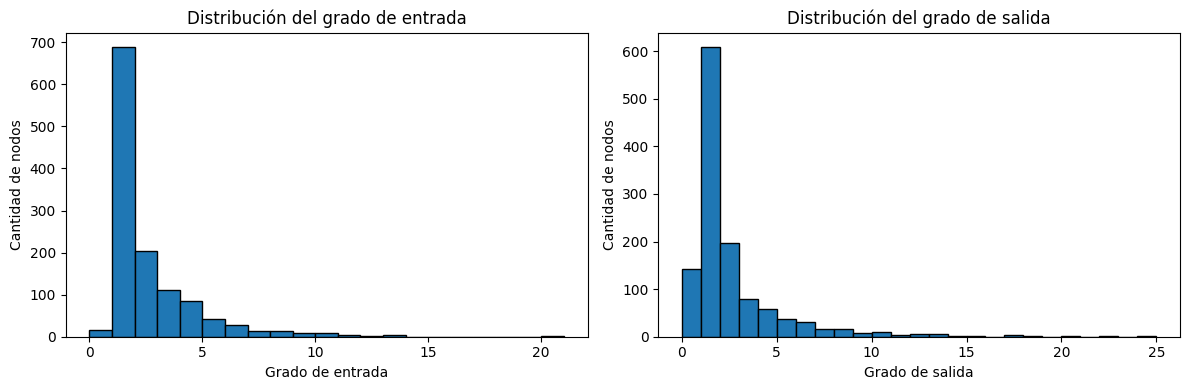

In [5]:
# (a) Distribución de grado de entrada y salida
in_deg_values = list(in_degrees.values())
out_deg_values = list(out_degrees.values())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# bins=range(0, max+2) asegura un bin por cada valor entero de grado posible.
axes[0].hist(in_deg_values, bins=range(0, max(in_deg_values)+2), edgecolor='black')
axes[0].set_title("Distribución del grado de entrada")
axes[0].set_xlabel("Grado de entrada")
axes[0].set_ylabel("Cantidad de nodos")

axes[1].hist(out_deg_values, bins=range(0, max(out_deg_values)+2), edgecolor='black')
axes[1].set_title("Distribución del grado de salida")
axes[1].set_xlabel("Grado de salida")
axes[1].set_ylabel("Cantidad de nodos")

plt.tight_layout()
plt.show()

Ambas distribuciones muestran una forma de "cola larga": la gran mayoría de los nodos tiene grado bajo (entre 1 y 3), mientras que muy pocos nodos concentran grados altos (hasta 20 en entrada y 25 en salida). Esta forma es típica de redes reales de infraestructura, donde existen unos pocos aeropuertos o centros de servicio que funcionan como concentradores (hubs) del sistema.

### P3.2 Nodos colgantes

In [6]:
# (b) Nodos colgantes
print(f"Cantidad de nodos colgantes (out-degree = 0): {num_colgantes}")
print(f"Porcentaje del total: {100*num_colgantes/n:.2f}%")

Cantidad de nodos colgantes (out-degree = 0): 143
Porcentaje del total: 11.66%


Los nodos colgantes son problemáticos para PageRank porque, en la matriz de hipervínculos $H$, la columna correspondiente a un nodo colgante queda completamente en cero (no hay ningún enlace de salida para repartir probabilidad). Esto rompe la propiedad de columna-estocástica que necesita la matriz para representar una cadena de Markov válida: la marcha aleatoria que llega a ese nodo no tendría ningún enlace real que seguir.

Este problema se resuelve con la matriz $S$, que reemplaza cada columna cero de $H$ por el vector uniforme $\mathbf{1}/n$. Esto equivale a decir que, al llegar a un nodo colgante, el agente de la marcha aleatoria salta uniformemente a cualquier otro nodo de la red, en vez de quedar atrapado.

### P3.3 Top 10 nodos por grado de entrada y de salida

In [7]:
# (c) Top-10 nodos por grado de entrada y por grado de salida

# sorted(diccionario.items(), key=lambda x: x[1], reverse=True) ordena las tuplas (nodo, grado)
# de mayor a menor grado; [:10] se queda solo con las 10 primeras.
top10_in = sorted(in_degrees.items(), key=lambda x: x[1], reverse=True)[:10]
top10_out = sorted(out_degrees.items(), key=lambda x: x[1], reverse=True)[:10]

df_top_in = pd.DataFrame(top10_in, columns=["nodo_id", "in_degree"])
df_top_out = pd.DataFrame(top10_out, columns=["nodo_id", "out_degree"])

print("Top 10 nodos por grado de entrada:")
print(df_top_in.to_string(index=False))

print("\nTop 10 nodos por grado de salida:")
print(df_top_out.to_string(index=False))

Top 10 nodos por grado de entrada:
 nodo_id  in_degree
     312         20
      68         13
      82         13
     110         13
     109         12
      52         11
     105         11
     135         11
      10         10
      34         10

Top 10 nodos por grado de salida:
 nodo_id  out_degree
      68          24
      52          22
      44          20
     113          20
      89          18
     187          18
      47          17
     312          17
     604          17
     212          15


El nodo 312 encabeza el ranking de grado de entrada (20) y también aparece entre los de mayor grado de salida (17), por lo que funciona como un hub bidireccional dentro de la red. El nodo 68, en cambio, tiene el mayor grado de salida (24) pero un grado de entrada más moderado (13), lo que sugiere que reparte tráfico hacia muchos otros nodos sin recibir tantas conexiones directas.

Este dataset no incluye nombres de aeropuertos, solo identificadores numéricos, por lo que el análisis a este nivel se limita a los IDs de nodo.

### P3.4 Conectividad de la red

In [8]:
# (d) Conectividad de la red

# nx.is_strongly_connected revisa si existe un camino dirigido entre cualquier par de nodos en ambos sentidos.
print("¿Es fuertemente conexa?:", nx.is_strongly_connected(G_nx))

# nx.number_strongly_connected_components cuenta cuántos "bloques" de ese tipo hay en el grafo.
num_scc = nx.number_strongly_connected_components(G_nx)
print(f"Número de componentes fuertemente conexas: {num_scc}")

# nx.strongly_connected_components devuelve cada componente como un set de nodos.
# Usamos max(..., key=len) para quedarnos con el set más grande.
largest_scc = max(nx.strongly_connected_components(G_nx), key=len)
print(f"Tamaño de la componente más grande: {len(largest_scc)} de {n} nodos")

¿Es fuertemente conexa?: False
Número de componentes fuertemente conexas: 434
Tamaño de la componente más grande: 792 de 1226 nodos


La red **no** es fuertemente conexa: existen 434 componentes fuertemente conexas, y la más grande cubre 792 de los 1 226 nodos (~65%). Esto es razonable en el contexto de rutas de tráfico aéreo, ya que muchas rutas preferentes son de "ida" sin que exista necesariamente una ruta de "vuelta" directa registrada, y probablemente existan subsistemas regionales aislados entre sí.

Esta falta de conectividad fuerte no es un problema para PageRank: la matriz de Google $G$ es siempre irreducible y aperiódica (ergódica) independientemente de la estructura del grafo subyacente, gracias al término de teletransporte $\frac{1-\alpha}{n}\mathbf{1}\mathbf{1}^T$, que permite saltar desde cualquier nodo hacia cualquier otro con probabilidad positiva.

## P4. Construcción de la Matriz de Google

Construimos paso a paso la Matriz de Google $G$, siguiendo la convención vista en clase: primero la matriz de hipervínculos $H$, luego la corrección por nodos colgantes ($S$), y finalmente la combinación con el término de teletransporte ($G$).

Como la red tiene 1 226 nodos, trabajamos con matrices dispersas (`scipy.sparse`) mientras sea posible, dado que la densidad de $H$ es muy baja.

### P4.1 Matriz de hipervínculos $H$

Definimos $H \in \mathbb{R}^{n \times n}$ con $H_{ij} = 1/\text{out}(j)$ si existe un enlace $j \to i$, y 0 en caso contrario. Cada columna de $H$ suma 1 cuando el nodo fuente $j$ no es colgante, porque estamos repartiendo la probabilidad total (1) de forma uniforme entre todos los enlaces de salida de $j$. Las columnas cero corresponden exactamente a los nodos colgantes identificados en P3.2.

In [9]:
# (a) Matriz de hipervínculos H

# Los nodos vienen con IDs originales (no necesariamente 0..n-1 ni consecutivos),
# así que armamos un diccionario idx que mapea cada nodo a un índice de matriz 0..n-1.
nodos = sorted(G_nx.nodes())
n = len(nodos)
idx = {nodo: i for i, nodo in enumerate(nodos)}

# Construimos H en formato disperso (COO): guardamos solo las entradas distintas de cero.
# Por cada arista (u, v) en el grafo (u -> v), la entrada H[i,j] correspondiente es 1/out(u),
# donde j es el índice de u (columna = origen) e i es el índice de v (fila = destino).
filas = []     # índice destino (i)
columnas = []  # índice origen (j)
datos = []     # valor 1/out(j) para esa entrada

for u, v in G_nx.edges():
    j = idx[u]  # nodo origen
    i = idx[v]  # nodo destino
    out_j = out_degrees[u]
    filas.append(i)
    columnas.append(j)
    datos.append(1.0 / out_j)

# sp.csr_matrix((datos, (filas, columnas)), shape=(n, n)) arma la matriz dispersa
# a partir de las tres listas paralelas (valor, fila, columna).
H = sp.csr_matrix((datos, (filas, columnas)), shape=(n, n))

# Verificación: las columnas no colgantes deben sumar 1.
# H.sum(axis=0) suma cada columna; .flatten() lo convierte de matriz a vector 1D.
suma_columnas = np.array(H.sum(axis=0)).flatten()
nodos_no_colgantes = [idx[nodo] for nodo, d in out_degrees.items() if d > 0]
print("¿Todas las columnas no colgantes suman 1?:",
      np.allclose(suma_columnas[nodos_no_colgantes], 1.0))

# Identificamos las columnas cero (nodos colgantes) directamente desde H,
# buscando qué índices de columna tienen suma exactamente 0.
columnas_cero = np.where(suma_columnas == 0)[0]
print(f"Columnas cero encontradas: {len(columnas_cero)}")
print(f"Coincide con nodos colgantes contados antes ({num_colgantes}):",
      len(columnas_cero) == num_colgantes)

¿Todas las columnas no colgantes suman 1?: True
Columnas cero encontradas: 143
Coincide con nodos colgantes contados antes (143): True


### P4.2 Matriz columna-estocástica $S$

Reparamos los nodos colgantes reemplazando cada columna cero de $H$ por el vector $\mathbf{1}/n$, de modo que $S = H + \frac{1}{n}\,\mathbf{1}\,\mathbf{a}^T$, donde $a_j = 1$ si el nodo $j$ es colgante y 0 si no. Con esto, todas las columnas de $S$ suman exactamente 1.

In [10]:
# (b) Matriz columna-estocástica S

# Vector indicador a: a[j] = 1 si el nodo j es colgante, 0 si no.
# columnas_cero ya trae los índices de los nodos colgantes calculados en el paso anterior.
a = np.zeros(n)
a[columnas_cero] = 1.0

# S = H + (1/n) * 1 * a^T.
# np.outer(unos, a) arma la matriz n x n donde la entrada (i,j) = unos[i] * a[j] = a[j];
# es decir, cada columna j queda llena con el valor a[j] (1/n si el nodo j es colgante, 0 si no).
# Esto agrega 1/n a cada fila de las columnas que eran cero en H, dejándolas uniformes.
unos = np.ones(n)
correccion = sp.csr_matrix((1.0 / n) * np.outer(unos, a))

S = H + correccion

suma_columnas_S = np.array(S.sum(axis=0)).flatten()
print("¿Todas las columnas de S suman 1?:", np.allclose(suma_columnas_S, 1.0))

¿Todas las columnas de S suman 1?: True


### P4.3 Matriz de Google $G$

Construimos $G = \alpha S + \frac{1-\alpha}{n}\mathbf{1}\mathbf{1}^T$, con $\alpha = 0.85$. Este es el valor clásico usado originalmente por Google: representa que un usuario sigue un enlace real el 85% del tiempo, y salta a un nodo al azar el 15% restante, balanceando entre respetar la estructura real de la red y garantizar buena convergencia.

Todas las entradas de $G$ son estrictamente positivas porque el término $\frac{1-\alpha}{n}\mathbf{1}\mathbf{1}^T$ suma un valor positivo a *todas* las entradas de la matriz, sin importar si $S$ tenía ceros ahí. Esto es justamente lo que garantiza que $G$ sea irreducible y aperiódica (ergódica), independientemente de la estructura del grafo original (que, como vimos en P3.4, no era fuertemente conexo).

In [11]:
# (c) Matriz de Google G
alpha = 0.85

# S ya quedó densa en la práctica por la corrección de nodos colgantes (casi ninguna columna
# sigue siendo dispersa), así que de aquí en adelante trabajamos con matrices densas para G;
# es perfectamente manejable en memoria para n=1226 (matriz de ~1.5M números).
S_dense = S.toarray()

# np.ones((n, n)) es la matriz de puros 1 (equivalente a 1 * 1^T).
G = alpha * S_dense + (1 - alpha) / n * np.ones((n, n))

print("¿Todas las entradas de G son estrictamente positivas?:", np.all(G > 0))
print("¿Columnas de G suman 1?:", np.allclose(G.sum(axis=0), 1.0))

¿Todas las entradas de G son estrictamente positivas?: True
¿Columnas de G suman 1?: True


## P5. Cálculo de PageRank mediante iteración de potencias

Implementamos la iteración de potencias para resolver $G\mathbf{r} = \mathbf{r}$, comenzando desde el vector uniforme $\mathbf{r}^{(0)} = \mathbf{1}/n$.

### P5.1 Iteración de potencias

In [12]:
# (a) Iteración de potencias
epsilon = 1e-10

# Partimos desde el vector uniforme: cada nodo arranca con la misma probabilidad 1/n.
r = np.ones(n) / n
errores = []  # guardamos el error de cada iteración para graficar la convergencia después

k = 0
while True:
    # G @ r es el producto matriz-vector: aplica un paso más de la marcha aleatoria sobre r.
    r_next = G @ r

    # np.linalg.norm(..., ord=1) calcula la norma 1 (suma de valores absolutos) de la diferencia,
    # que es la métrica de error que pide el enunciado.
    error = np.linalg.norm(r_next - r, ord=1)
    errores.append(error)
    r = r_next
    k += 1

    if error < epsilon:
        break

print(f"Convergió en {k} iteraciones")
print(f"Suma de r*: {r.sum():.10f}")
print(f"¿Todos los valores son positivos?: {np.all(r > 0)}")

Convergió en 52 iteraciones
Suma de r*: 1.0000000000
¿Todos los valores son positivos?: True


La iteración convergió en 52 pasos, con $\|\mathbf{r}^*\|_1 = 1$ y todos los valores estrictamente positivos, tal como predice la teoría.

### P5.2 Curva de convergencia

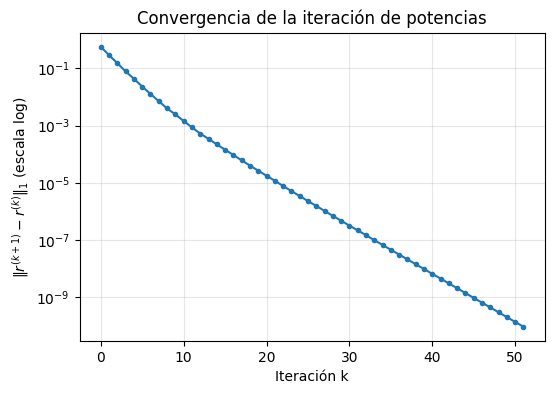

Razón de decaimiento promedio (últimas 10 iteraciones): 0.6786
Valor de alpha usado: 0.85


In [13]:
# (b) Curva de convergencia
plt.figure(figsize=(6, 4))
plt.semilogy(errores, marker='o', markersize=3)
plt.xlabel("Iteración k")
plt.ylabel(r"$\|r^{(k+1)} - r^{(k)}\|_1$ (escala log)")
plt.title("Convergencia de la iteración de potencias")
plt.grid(True, which="both", alpha=0.3)
plt.show()

# Calculamos la razón entre errores consecutivos (errores[i+1] / errores[i]) para estimar
# la tasa de decaimiento geométrico, y promediamos las últimas 10 razones (ya estabilizadas).
razones = [errores[i+1] / errores[i] for i in range(len(errores) - 1) if errores[i] > 0]
print(f"Razón de decaimiento promedio (últimas 10 iteraciones): {np.mean(razones[-10:]):.4f}")
print(f"Valor de alpha usado: {alpha}")

El error decae de forma geométrica (línea recta en escala logarítmica), como predice la teoría. La razón de decaimiento empírica obtenida (≈0.68) es más rápida que la cota teórica de $\alpha = 0.85$: esto es normal, ya que $\alpha$ es una cota superior para el peor caso (cuando el segundo valor propio de $S$ está muy cerca de 1), mientras que la brecha espectral real de esta red específica permite una convergencia algo más rápida.

### P5.3 Verificaciones teóricas

In [14]:
# (c) Verificaciones
print(f"||r*||_1 = {np.sum(np.abs(r)):.10f}  (debe ser 1)")
print(f"Mínimo valor de r*: {r.min():.2e}  (debe ser > 0)")

||r*||_1 = 1.0000000000  (debe ser 1)
Mínimo valor de r*: 2.13e-04  (debe ser > 0)


Ambas propiedades están garantizadas por la teoría: $\|\mathbf{r}^*\|_1 = 1$ porque $G$ es columna-estocástica (cada iteración preserva la suma total de probabilidad), y $r_i^* > 0$ para todo $i$ porque $G$ tiene todas sus entradas estrictamente positivas, lo que implica (Perron-Frobenius) que el vector propio estacionario de una cadena de Markov ergódica es siempre estrictamente positivo.

### P5.4 Top 20 nodos por PageRank

In [15]:
# (d) Top 20 nodos por PageRank

# Reconstruimos el diccionario {nodo_original: pagerank} usando la lista 'nodos'
# que guarda el orden en que se asignaron los índices de matriz.
pagerank_dict = {nodos[i]: r[i] for i in range(n)}

top20 = sorted(pagerank_dict.items(), key=lambda x: x[1], reverse=True)[:20]

df_top20 = pd.DataFrame(top20, columns=["nodo_id", "pagerank"])
df_top20["rango"] = range(1, 21)

# .map(diccionario) busca, para cada nodo_id de la columna, su grado correspondiente.
df_top20["in_degree"] = df_top20["nodo_id"].map(in_degrees)
df_top20["out_degree"] = df_top20["nodo_id"].map(out_degrees)
df_top20 = df_top20[["rango", "nodo_id", "pagerank", "in_degree", "out_degree"]]

print(df_top20.to_string(index=False))

 rango  nodo_id  pagerank  in_degree  out_degree
     1      312  0.007708         20          17
     2       61  0.005693          8           0
     3      105  0.005344         11           1
     4       19  0.005165          7           0
     5      842  0.004756          1           1
     6      187  0.004476          9          18
     7      578  0.004384          2           2
     8       86  0.004263         10           2
     9       52  0.003951         11          22
    10      311  0.003874          8           4
    11       38  0.003788          8           0
    12       26  0.003765          9           0
    13       68  0.003553         13          24
    14      201  0.003347          7           7
    15      306  0.003334          5           9
    16      109  0.003312         12          10
    17       44  0.003002          8          20
    18      157  0.002941          9          12
    19       89  0.002907          8          18
    20      266  0.0

El nodo 312 encabeza el ranking de PageRank, consistente con nuestra hipótesis, ya que combina alto grado de entrada (20) y buen grado de salida (17). Sin embargo, ya aparecen los primeros indicios de que PageRank captura algo más que el grado de entrada: por ejemplo, el nodo 19 tiene grado de entrada 7 y grado de salida 0 (es colgante), pero queda en el puesto #4; y el nodo 842 tiene grado de entrada de solo 1, pero aparece en el puesto #5. Ambos casos se analizan en detalle en P6.

## P6. PageRank vs. grado de entrada

Comparamos el PageRank con la centralidad de grado de entrada para ver si PageRank aporta información adicional respecto a un conteo simple de enlaces entrantes.

### P6.1 Correlación entre PageRank y grado de entrada

Correlación de Pearson (in-degree vs PageRank): 0.7972
p-value: 1.55e-270


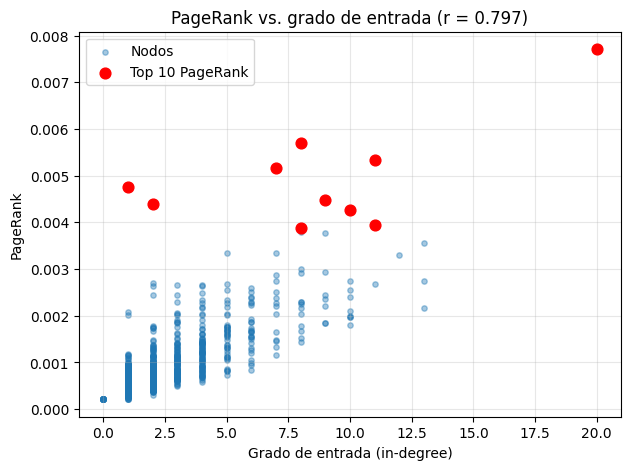

In [16]:
# (a) Grado de entrada vs. PageRank

# Armamos un arreglo de in-degree en el mismo orden que 'nodos', para que sea comparable
# elemento a elemento con el vector r (el vector de PageRank ya está en ese orden).
in_deg_array = np.array([in_degrees[nodo] for nodo in nodos])
pagerank_array = r

# pearsonr devuelve (coeficiente de correlación, p-value) entre los dos arreglos.
corr, p_value = pearsonr(in_deg_array, pagerank_array)
print(f"Correlación de Pearson (in-degree vs PageRank): {corr:.4f}")
print(f"p-value: {p_value:.2e}")

# np.argsort ordena de menor a mayor y devuelve los índices; con [-10:] tomamos
# los índices de los 10 valores de PageRank más altos.
top10_idx = np.argsort(pagerank_array)[-10:]

plt.figure(figsize=(7, 5))
plt.scatter(in_deg_array, pagerank_array, alpha=0.4, s=15, label="Nodos")
plt.scatter(in_deg_array[top10_idx], pagerank_array[top10_idx],
            color='red', s=60, label="Top 10 PageRank", zorder=5)
plt.xlabel("Grado de entrada (in-degree)")
plt.ylabel("PageRank")
plt.title(f"PageRank vs. grado de entrada (r = {corr:.3f})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

La correlación de Pearson entre grado de entrada y PageRank es 0.797: una relación fuerte, pero no perfecta. Esto confirma la primera parte de nuestra hipótesis (los nodos con más grado de entrada tienden a tener mayor PageRank), pero deja espacio para casos particulares donde ambas medidas difieren, que exploramos a continuación.

### P6.2 Nodos donde PageRank e in-degree difieren

Para identificar casos genuinamente divergentes, comparamos los rangos (posiciones relativas) de cada nodo según grado de entrada y según PageRank, filtrando primero a los nodos que sí tienen un grado de entrada alto en términos absolutos (percentil 90 o más), ya que muchos nodos comparten grados bajos y eso puede generar diferencias de rango poco informativas.

In [17]:
# (b) Nodos con divergencia entre in-degree y PageRank

# rankdata(-arreglo) asigna rango 1 al valor más grande del arreglo original
# (el signo negativo invierte el orden, ya que rankdata por defecto ordena de menor a mayor).
rank_in_degree = rankdata(-in_deg_array)
rank_pagerank = rankdata(-pagerank_array)

df_comparacion = pd.DataFrame({
    "nodo_id": nodos,
    "in_degree": in_deg_array,
    "pagerank": pagerank_array,
    "rango_in_degree": rank_in_degree.astype(int),
    "rango_pagerank": rank_pagerank.astype(int),
})
# Si el rango de in-degree es mucho menor (mejor) que el rango de PageRank, la diferencia
# es negativa (in-degree alto, PageRank relativamente bajo), y viceversa.
df_comparacion["diferencia_rango"] = df_comparacion["rango_in_degree"] - df_comparacion["rango_pagerank"]

# Caso 1: in-degree genuinamente alto (percentil 90+) pero PageRank relativamente bajo.
# np.percentile calcula el valor bajo el cual cae el 90% de los datos.
umbral_alto = np.percentile(in_deg_array, 90)
print(f"Umbral de 'alto in-degree' (percentil 90): {umbral_alto}")

mask_alto_indegree = df_comparacion["in_degree"] >= umbral_alto
caso1 = df_comparacion[mask_alto_indegree].sort_values("pagerank").head(5)
print("\nNodos con in-degree ALTO pero PageRank relativamente BAJO:")
print(caso1.to_string(index=False))

# Caso 2: PageRank alto pero in-degree moderado/bajo (mayor diferencia de rango positiva).
caso2 = df_comparacion.sort_values("diferencia_rango", ascending=False).head(5)
print("\nNodos con PageRank ALTO pero in-degree MODERADO:")
print(caso2.to_string(index=False))

Umbral de 'alto in-degree' (percentil 90): 4.0

Nodos con in-degree ALTO pero PageRank relativamente BAJO:
 nodo_id  in_degree  pagerank  rango_in_degree  rango_pagerank  diferencia_rango
     220          4  0.000577              164             660              -496
     470          4  0.000615              164             595              -431
      92          4  0.000665              164             534              -370
     469          4  0.000699              164             490              -326
     481          4  0.000699              164             490              -326

Nodos con PageRank ALTO pero in-degree MODERADO:
 nodo_id  in_degree  pagerank  rango_in_degree  rango_pagerank  diferencia_rango
     842          1  0.004756              866               5               861
     582          1  0.002076              866              65               801
     396          1  0.002025              866              74               792
     418          1  0.001191    

In [18]:
# Investigamos el caso del nodo 842: in-degree bajo (1) pero PageRank alto (puesto #5).
# G_nx.predecessors(nodo) devuelve los nodos que tienen una arista apuntando hacia 'nodo'.
predecesores_842 = list(G_nx.predecessors(842))
print(f"Nodo(s) que enlazan a 842: {predecesores_842}")
for p in predecesores_842:
    print(f"  Nodo {p}: in_degree={in_degrees[p]}, out_degree={out_degrees[p]}, PageRank={pagerank_dict[p]:.5f}")

Nodo(s) que enlazan a 842: [105]
  Nodo 105: in_degree=11, out_degree=1, PageRank=0.00534


El caso más claro de divergencia es el nodo 842: tiene grado de entrada de solo 1, pero queda en el puesto #5 de PageRank. Al investigar quién lo enlaza, encontramos que su único predecesor es el nodo 105, que tiene grado de entrada 11 y un PageRank alto (0.00534, dentro del top-10). Es decir, el nodo 842 hereda importancia del nodo 105: no importa cuántos enlaces entrantes tiene un nodo, sino qué tan importantes son los nodos que lo enlazan. Este es el ejemplo más directo de por qué PageRank no es simplemente un conteo de enlaces, sino una medida recursiva de relevancia.

Por otro lado, los nodos con grado de entrada alto (percentil 90, es decir, in-degree ≥ 4) pero PageRank relativamente bajo corresponden a nodos que reciben varios enlaces, pero de nodos que a su vez son poco relevantes, por lo que no heredan mayor importancia.

## P7. Interpretación de resultados

### P7.1 Nodos de mayor PageRank en contexto

Los nodos de mayor PageRank (312, 61, 105, 19, 842, ...) tienen sentido como nodos influyentes dentro de la red: combinan buen grado de entrada y/o salida, o bien están enlazados por otros nodos relevantes (como 842, enlazado por 105). Como el dataset no incluye nombres de aeropuertos, la interpretación queda a nivel de estructura de la red más que de identificación geográfica específica.

### P7.2 Visualización del subgrafo de mayor PageRank

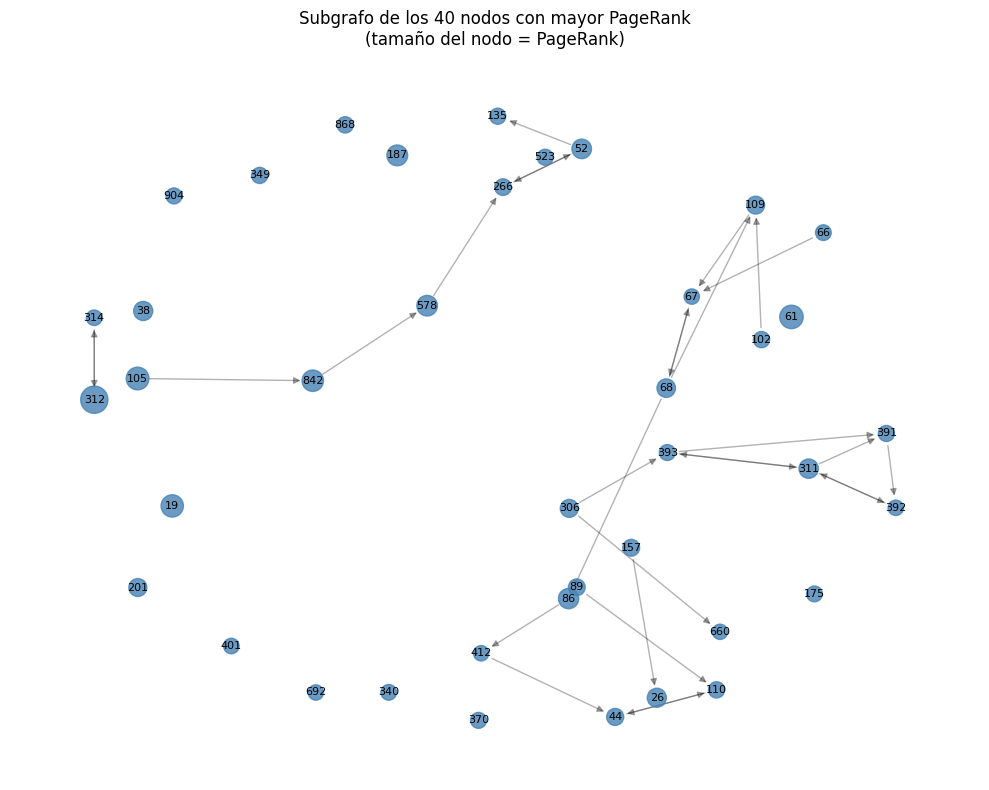

In [19]:
# Subgrafo de los 40 nodos con mayor PageRank, escalados por PageRank
top_n = 40
top_nodos_ids = [nodo for nodo, _ in sorted(pagerank_dict.items(), key=lambda x: x[1], reverse=True)[:top_n]]

# G_nx.subgraph(lista_de_nodos) devuelve la vista del grafo original restringida solo
# a esos nodos y a las aristas que van entre ellos.
subgrafo = G_nx.subgraph(top_nodos_ids)

plt.figure(figsize=(10, 8))
# spring_layout ubica los nodos usando un modelo de fuerzas (como resortes en las aristas)
# para que la disposición visual refleje mejor la estructura del grafo. seed=42 la hace reproducible.
pos = nx.spring_layout(subgrafo, seed=42, k=0.5)

# Escalamos el tamaño de cada nodo proporcional a su PageRank (multiplicamos por una constante
# grande porque los valores de PageRank son muy pequeños en magnitud).
tamanos = [pagerank_dict[nodo] * 50000 for nodo in subgrafo.nodes()]

nx.draw_networkx_nodes(subgrafo, pos, node_size=tamanos, node_color='steelblue', alpha=0.8)
nx.draw_networkx_edges(subgrafo, pos, alpha=0.3, arrows=True, arrowsize=10)
nx.draw_networkx_labels(subgrafo, pos, font_size=8)

plt.title(f"Subgrafo de los {top_n} nodos con mayor PageRank\n(tamaño del nodo = PageRank)")
plt.axis('off')
plt.tight_layout()
plt.show()

El subgrafo inducido por los 40 nodos de mayor PageRank no forma un solo bloque conectado, sino varios grupos pequeños (por ejemplo, {312-314-105-842-578-266-52-523}, {391-392-311-393} y {68-109-67-61-102-66}), además de varios nodos que aparecen aislados dentro de este subgrafo (868, 187, 349, 904, 38, 19, 201, 401, 692, 340, 175, 370).

Estos nodos "aislados" en el gráfico sí tienen conexiones en la red completa, pero sus vecinos no están entre los top-40; es decir, su PageRank alto proviene de vínculos con nodos fuera del grupo de mayor importancia, no de pertenecer a un grupo de nodos importantes interconectados entre sí. Esto es consistente con lo observado en P3.4: la red completa tiene 434 componentes fuertemente conexas, por lo que el sistema de tráfico aéreo modelado aquí parece estar fragmentado en múltiples subsistemas regionales.

Este dataset no incluye atributos de nodo (categoría, región, tipo de aeropuerto), por lo que no fue posible colorear el subgrafo según ningún atributo adicional; esta limitación se retoma en la discusión final (P8).

## P8. Discusión, limitaciones y conclusiones

La pregunta planteada en P2 quedó respondida: identificamos que el nodo 312 es el más central de la red, combinando buen grado de entrada y de salida. Sin embargo, el análisis también reveló casos como el del nodo 842, donde el PageRank capturó una importancia "heredada" que el grado de entrada por sí solo no era capaz de ver.

En cuanto a la hipótesis inicial, esta se cumplió parcialmente. La correlación de 0.797 entre grado de entrada y PageRank confirma que ambas medidas están relacionadas, pero encontramos casos claros (como el nodo 842, enlazado únicamente por el nodo 105) donde PageRank capturó posición estratégica más allá de lo que sugiere el grado de entrada, validando la segunda parte de la hipótesis.

El método tiene algunas limitaciones importantes en este contexto. Un 11.66% de nodos colgantes es una fracción considerable, y sin la corrección introducida por la matriz $S$ el modelo se rompería. La red tampoco es fuertemente conexa (434 componentes), por lo que un modelo de marcha aleatoria "pura", sin el término de teletransporte de $G$, no sería válido. Además, la red es bastante dispersa (densidad 0.0017), lo cual es coherente con tratarse de infraestructura real y no de una red social densa. Finalmente, el dataset no incluye metadata de los nodos (nombres de aeropuertos, región, tipo), lo que limita la profundidad de la interpretación cualitativa; un trabajo futuro podría enriquecer este análisis cruzando los IDs con una base de datos de aeropuertos de la FAA.

Del análisis surgieron preguntas nuevas que no habíamos anticipado al comienzo, como por ejemplo: ¿qué caracteriza a los subsistemas regionales que se observan en el subgrafo de mayor PageRank?, y ¿por qué una fracción tan alta de nodos son colgantes dentro de este dataset de rutas preferentes?

Si tuviéramos que explicar el resultado principal a alguien sin conocimientos técnicos, lo describiríamos así: imaginemos un avión fantasma que vuela sin parar siguiendo rutas reales entre aeropuertos, y que de vez en cuando se aburre y salta a un aeropuerto al azar. Los aeropuertos más "importantes" son los que ese avión fantasma visita más seguido a largo plazo, y no necesariamente los que reciben más vuelos directos, sino los que están bien conectados con otros aeropuertos que también son importantes.